<h2>Domain embeddings & restrictions</h2>

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import troma
from troma import data_structure as ds
from troma import ConstraintSketch, ExplicitSketch
from troma import bind_optimizer, get_optimizer, optimize
from troma import matching_pursuit, get_matching_pursuit, bind_matching_pursuit
from troma import mcco_modeling
from troma import solve_via_mcco

In [8]:
from troma.embedding import spectrum_embedding, spectrum_restriction, reverse_spectrum_restriction

from problems_generator import compressive_sensing_pb as cs_pb, compressible_opt_pb as co_pb

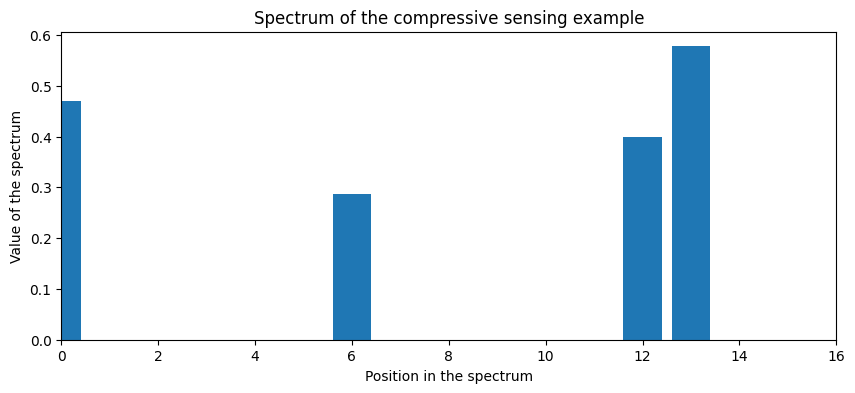

In [9]:
spectrum_pos, spectrum_val, spectrum_bin = cs_pb.generate_random_problem(4, 4)
plt.figure(figsize=(10, 4))
plt.bar(spectrum_pos, spectrum_val)
plt.xlim(0, 16)
plt.xlabel("Position in the spectrum")
plt.ylabel("Value of the spectrum")
plt.title("Spectrum of the compressive sensing example")
plt.show()

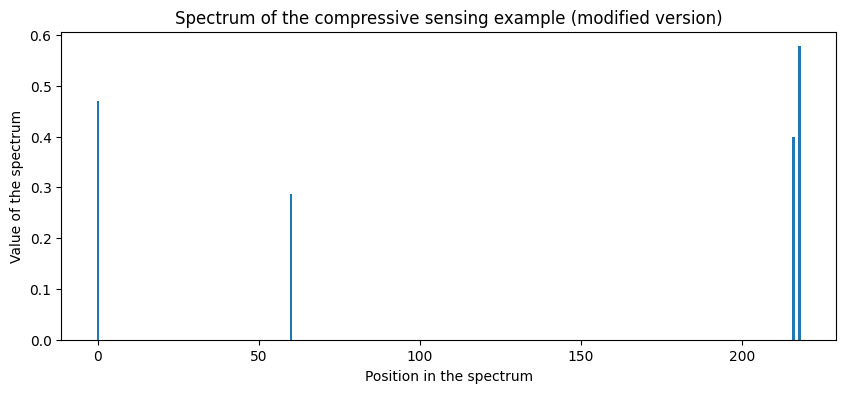

In [10]:
spectrum_emb = spectrum_embedding(spectrum_bin, additional_dits=[0,3], dimension_mapping={0: 0, 1: 2})
emb_pos = [ds.dit_string_to_integer(s, dit_dimension=3) for s in spectrum_emb]

plt.figure(figsize=(10, 4))
plt.bar(emb_pos, spectrum_val)
plt.xlabel("Position in the spectrum")
plt.ylabel("Value of the spectrum")
plt.title("Spectrum of the compressive sensing example (modified version)")
plt.show()

In [11]:
print(spectrum_emb)
print(reverse_spectrum_restriction(spectrum_restriction(spectrum_emb, dit_restrictions=[1,2,4,5], dit_value_restrictions=[0,2]), 6, dit_restrictions=[1,2,4,5], dit_value_restrictions=[0,2]))

[array([0, 0, 0, 0, 0, 0]), array([0, 0, 2, 0, 2, 0]), array([0, 2, 2, 0, 0, 0]), array([0, 2, 2, 0, 0, 2])]
[array([0, 0, 0, 0, 0, 0]), array([0, 0, 2, 0, 2, 0]), array([0, 2, 2, 0, 0, 0]), array([0, 2, 2, 0, 0, 2])]


------------------------------------------

<h2>Full Pipeline</h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import troma
from troma import data_structure as ds
from troma import ConstraintSketch, ExplicitSketch
from troma import bind_optimizer, get_optimizer, optimize
from troma import matching_pursuit, get_matching_pursuit, bind_matching_pursuit
from troma import mcco_modeling
from troma import solve_via_mcco

In [2]:
from troma.embedding import spectrum_embedding, spectrum_restriction, reverse_spectrum_restriction

from problems_generator import compressive_sensing_pb as cs_pb, compressible_opt_pb as co_pb

In [3]:
number_spins = 12
rules_reward = {(0, 0, 0, 0): 18, (1, 1, 0, 1): 5, (1, 1, 1, 1): 18}

full_spectrum = co_pb.compute_full_spectrum(number_spins, rules_reward)
print(np.where(full_spectrum == np.max(full_spectrum)))
spectrum_pos = []
spectrum_val = []
spectrum_bin = []
for i,j in enumerate(full_spectrum):
    spectrum_pos.append(i)
    spectrum_val.append(j)
    spectrum_bin.append( ds.integer_to_dit_string(i, 12) )

# plt.bar(spectrum_pos, spectrum_val)
# plt.show()

(array([   0, 4095]),)


In [4]:
emb_spectrum = spectrum_embedding(spectrum_bin, additional_dits=[0], dimension_mapping=None, additional_dits_val=1)
emb_pos = [ds.dit_string_to_integer(s, dit_dimension=2) for s in emb_spectrum]
full_emb_spectrum = np.zeros((2**13,))
for pos, val in zip(emb_pos, spectrum_val):
    full_emb_spectrum[pos] = val

print(np.where(full_emb_spectrum == np.max(full_emb_spectrum)))
# plt.bar(range(len(full_emb_spectrum)), full_emb_spectrum)
# plt.show()

(array([4096, 8191]),)


In [5]:
def ev_conf(conf):
    return full_emb_spectrum[ds.dit_string_to_integer(conf, dit_dimension=2)]

In [8]:
from troma import embedding_and_solve_via_mcco

res = embedding_and_solve_via_mcco(
    ev_conf,
    dit_string_length=13,
    dit_restrictions=np.arange(1,13),
    dit_value_restrictions=None,
    number_samples = 400,
    interaction_size = 4,
    additional_dits_val=1,
    iteration_number=5,
    step=None,
    threshold_parameter="Auto",
    dit_dimension=2,
    optimizer=None,
    optimizer_name="spin_chain_nn_max",
)
res["solution_pos"]

[8191, 4096, 6926, 7677, 6378]

In [9]:
res = solve_via_mcco(
    ev_conf,
    dit_string_length=13,
    number_samples = 400,
    interaction_size = 4,
    iteration_number=5,
    step=None,
    threshold_parameter="Auto",
    dit_dimension=2,
    optimizer=None,
    optimizer_name="spin_chain_nn_max",
)
res["solution_pos"]

array([8176, 6145, 6143, 7620, 4121])

In [10]:
import numpy as np
from troma import embedding_and_solve_via_mcco, solve_via_mcco

def max_positions(spectrum):
    return set(np.where(np.asarray(spectrum) == np.max(spectrum))[0])

max_pos = max_positions(full_emb_spectrum)

def hit_by_solution_pos(result):
    positions = result.get("solution_pos", [])
    return bool(set(positions) & max_pos)

def evaluate_success(n_trials, number_samples):
    emb_hits = 0
    full_hits = 0
    for seed in range(n_trials):
        np.random.seed(seed)
        res_emb = embedding_and_solve_via_mcco(
            ev_conf,
            dit_string_length=13,
            dit_restrictions=np.arange(1,13),
            dit_value_restrictions=None,
            number_samples=number_samples,
            interaction_size=4,
            additional_dits_val=1,
            iteration_number=5,
            step=None,
            threshold_parameter="Auto",
            dit_dimension=2,
            optimizer=None,
            optimizer_name="spin_chain_nn_max",
        )
        emb_hits += int(hit_by_solution_pos(res_emb))

        np.random.seed(seed)
        res_full = solve_via_mcco(
            ev_conf,
            dit_string_length=13,
            number_samples=number_samples,
            interaction_size=4,
            iteration_number=5,
            step=None,
            threshold_parameter="Auto",
            dit_dimension=2,
            optimizer=None,
            optimizer_name="spin_chain_nn_max",
        )
        full_hits += int(hit_by_solution_pos(res_full))

    return emb_hits, full_hits

for number_samples in [50, 100, 150]:
    emb_hits, full_hits = evaluate_success(20, number_samples)
    print(f"number_samples={number_samples}: embedding_hits={emb_hits}/20, full_hits={full_hits}/20")


number_samples=50: embedding_hits=2/20, full_hits=0/20
number_samples=100: embedding_hits=6/20, full_hits=2/20
number_samples=150: embedding_hits=10/20, full_hits=5/20
